## Welcome to Scikit Learn

In [117]:
## Get the data ready
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
heart_disease=pd.read_csv("heart-disease.csv")

In [118]:
heart_disease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [119]:
x=heart_disease.drop("target",axis=1)
y=heart_disease["target"]

In [120]:
## Choose the right model
from sklearn.ensemble import RandomForestClassifier

In [121]:
clf=RandomForestClassifier(n_estimators=100)

In [122]:
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [123]:
from sklearn.model_selection import train_test_split

In [124]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [125]:
clf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [126]:
y_preds=clf.predict(x_test)

In [127]:
y_preds

array([1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0])

In [128]:
## Evaluate

In [129]:
clf.score(x_train,y_train)

1.0

In [130]:
clf.score(x_test,y_test)

0.8688524590163934

In [131]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [132]:
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87        31
           1       0.87      0.87      0.87        30

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



In [133]:
print(confusion_matrix(y_test,y_preds))

[[27  4]
 [ 4 26]]


In [134]:
print(accuracy_score(y_test,y_preds))

0.8688524590163934


In [135]:
## imprpoving the model

In [136]:
np.random.seed(42)
for i in range(10, 100, 10):
    print(f"trying model {i}")
    clf = RandomForestClassifier(n_estimators=i).fit(x_train, y_train)
    print(f"model set: {clf.score(x_test, y_test) * 100:.2f}%")
    print(" ")

trying model 10
model set: 78.69%
 
trying model 20
model set: 86.89%
 
trying model 30
model set: 85.25%
 
trying model 40
model set: 85.25%
 
trying model 50
model set: 85.25%
 
trying model 60
model set: 88.52%
 
trying model 70
model set: 86.89%
 
trying model 80
model set: 86.89%
 
trying model 90
model set: 88.52%
 


In [137]:
##save model

In [138]:
import pickle

In [139]:
pickle.dump(clf,open("randomForest1.pkl","wb"))

In [140]:
loaded_model=pickle.load(open("randomForest1.pkl","rb"))

In [141]:
loaded_model.score(x_test,y_test)

0.8852459016393442

## Getting data Ready


In [142]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [143]:
x=heart_disease.drop("target",axis=1)

In [144]:
y=heart_disease["target"]

In [145]:
from sklearn.model_selection import train_test_split

In [146]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [147]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((242, 13), (61, 13), (242,), (61,))

## Make sure that it is numbered

In [148]:
car_sales=pd.read_csv("car-sales.csv")

In [149]:
car_sales.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,"$4,000.00"
1,Honda,Red,87899,4,"$5,000.00"
2,Toyota,Blue,32549,3,"$7,000.00"
3,BMW,Black,11179,5,"$22,000.00"
4,Nissan,White,213095,4,"$3,500.00"


In [150]:
car_sales.dtypes

Make             object
Colour           object
Odometer (KM)     int64
Doors             int64
Price            object
dtype: object

In [151]:
x=car_sales.drop("Price",axis=1)
car_sales["Price"] = car_sales["Price"].str.replace("[$,]", "", regex=True).astype(float)
y=car_sales["Price"]

In [152]:
# ## split into training and test
# x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor()
# model.fit(x_train,y_train)
# model.score(x_test,y_test)
# ## The above will give error which we will resolve below

In [153]:
car_sales.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,4000.0
1,Honda,Red,87899,4,5000.0
2,Toyota,Blue,32549,3,7000.0
3,BMW,Black,11179,5,22000.0
4,Nissan,White,213095,4,3500.0


In [154]:
## Build machine learning model
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
categorical_features=["Make","Colour","Doors"]
one_hot=OneHotEncoder()
transformer=ColumnTransformer([("one_hot",
                                one_hot,
                                categorical_features)],
                              remainder="passthrough")
transformed_x=transformer.fit_transform(x)
transformed_x
pd.DataFrame(transformed_x)


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,150043.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,87899.0
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,32549.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,11179.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,213095.0
5,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,99213.0
6,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,45698.0
7,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,54738.0
8,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,60000.0
9,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,31600.0


In [155]:
np.random.seed(49)
x_train,x_test,y_train,y_test=train_test_split(transformed_x,
                                               y,
                                               test_size=0.2)
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.35196983687288397

## What is missing values are present in the data

In [156]:
## Fill them with some values (imputation)
## Remove the samples with missing data altogether

In [157]:
car_sales_missing=pd.read_csv("car-sales-missing-data.csv")

In [158]:
## You will get error if you try to convert the above data into numbers because of missing values so remediate it first
car_sales_missing.isna().sum()

Make        1
Colour      1
Odometer    4
Doors       1
Price       2
dtype: int64

In [159]:
car_sales_missing["Make"] = car_sales_missing["Make"].fillna("missing")
car_sales_missing["Colour"] = car_sales_missing["Colour"].fillna("missing")
car_sales_missing["Odometer"] = car_sales_missing["Odometer"].fillna(car_sales_missing["Odometer"].mean())
car_sales_missing["Doors"] = car_sales_missing["Doors"].fillna(4)
car_sales_missing.dropna(inplace=True)

In [160]:
x=car_sales_missing.drop("Price",axis=1)
car_sales_missing["Price"] = car_sales_missing["Price"].str.replace("[$,]", "", regex=True).astype(float)
y=car_sales_missing["Price"]

In [161]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
categorical_features=["Make","Colour","Doors"]
one_hot=OneHotEncoder()
transformer=ColumnTransformer([("one_hot",
                                one_hot,
                                categorical_features)],
                              remainder="passthrough")
transformed_x=transformer.fit_transform(x)
transformed_x

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 32 stored elements and shape (8, 15)>

In [162]:
np.random.seed(67)
x_train,x_test,y_train,y_test=train_test_split(transformed_x,
                                               y,
                                               test_size=0.2)
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.6448553401046475

## Fill missing values with scikit-learn(Always prioritize this)

In [163]:
car_missing=pd.read_csv("car-sales-extended-missing-data.csv")

In [164]:
car_missing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [165]:
car_missing.dropna(subset=["Price"],inplace=True)

In [166]:
car_missing.isna().sum()

Make             47
Colour           46
Odometer (KM)    48
Doors            47
Price             0
dtype: int64

In [167]:
## split into x and y
x=car_missing.drop("Price",axis=1)
y=car_missing["Price"]

In [168]:
## Fill missing values with scikit learn
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [169]:
## Fill categorical values with 'missing' and numerical with 'mean'
cat_imputer=SimpleImputer(strategy="constant",
                          fill_value="missing")
door_imputer=SimpleImputer(strategy="constant",
                           fill_value=4)
num_imputer=SimpleImputer(strategy="mean")

In [170]:
## Define
cat_features=["Make","Colour"]
door_features=["Doors"]
num_features=["Odometer (KM)"]

In [171]:
## Create an imputer(something that fills missing data)
imputer=ColumnTransformer([
    ("cat_imputer",cat_imputer,cat_features),
    ("door_imputer",door_imputer,door_features),
    ("num_imputer",num_imputer,num_features)
])
filled_x=imputer.fit_transform(x)
filled_x

array([['Honda', 'White', 4.0, 35431.0],
       ['BMW', 'Blue', 5.0, 192714.0],
       ['Honda', 'White', 4.0, 84714.0],
       ...,
       ['Nissan', 'Blue', 4.0, 66604.0],
       ['Honda', 'White', 4.0, 215883.0],
       ['Toyota', 'Blue', 4.0, 248360.0]], shape=(950, 4), dtype=object)

In [172]:
car_sales_filled=pd.DataFrame(filled_x,
                              columns=["Make","Colour","Doors","Odometer (KM)"])

In [173]:
car_sales_filled.isna().sum()

Make             0
Colour           0
Doors            0
Odometer (KM)    0
dtype: int64

In [174]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
categorical_features=["Make","Colour","Doors"]
one_hot=OneHotEncoder()
transformer=ColumnTransformer([("one_hot",
                                one_hot,
                                categorical_features)],
                              remainder="passthrough")
transformed_x=transformer.fit_transform(car_sales_filled)
transformed_x

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3800 stored elements and shape (950, 15)>

In [175]:
np.random.seed(42)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(transformed_x,
                                               y,
                                               test_size=0.2)
model=RandomForestRegressor()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.21990196728583944

In [176]:
len(car_sales_filled)

950

## In this section we will try to check how we can choose the right model

In [177]:
from sklearn.datasets import fetch_california_housing
housing=fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [178]:
housing_df=pd.DataFrame(housing["data"],columns=housing["feature_names"])
housing_df["MedHouseVal"]=housing["target"]
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [179]:
housing_df["target"]=housing["target"]
housing_df=housing_df.drop("MedHouseVal",axis=1)
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [180]:
from sklearn.linear_model import Ridge
np.random.seed(42)
x=housing_df.drop("target",axis=1)
y=housing_df["target"]
x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               test_size=0.2)
model=Ridge()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.5758549611440126

In [181]:
from sklearn.ensemble import RandomForestRegressor
np.random.seed(42)
x=housing_df.drop("target",axis=1)
y=housing_df["target"]
x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               test_size=0.2)
model=RandomForestRegressor()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.8059809073051385

## Choosing the best estimator/model/algorithm for Classification

In [182]:
heart_disease=pd.read_csv("heart-disease.csv")
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [183]:
from sklearn.svm import LinearSVC
np.random.seed(42)
x=heart_disease.drop("target",axis=1)
y=heart_disease["target"]
x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               test_size=0.2)
model=LinearSVC()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.8688524590163934

In [184]:
heart_disease["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [185]:
from sklearn.ensemble import RandomForestClassifier
np.random.seed(42)
x=heart_disease.drop("target",axis=1)
y=heart_disease["target"]
x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               test_size=0.2)
model=RandomForestClassifier()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.8524590163934426

## 3.2 Make predictions with predict()

In [186]:
x_test.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2


In [187]:
model.predict(x_test)

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [188]:
np.array(y_test)

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [189]:
y_preds=model.predict(x_test)
np.mean(y_preds==y_test)

np.float64(0.8524590163934426)

In [190]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_preds)

0.8524590163934426

## Make prediction with predict_proba()

In [191]:
model.predict_proba(x_test[:5])

array([[0.89, 0.11],
       [0.49, 0.51],
       [0.43, 0.57],
       [0.84, 0.16],
       [0.18, 0.82]])

In [192]:
model.predict(x_test[:5])

array([0, 1, 1, 0, 1])

## Using Predict on Regresssion

In [193]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [194]:
from sklearn.ensemble import RandomForestRegressor
np.random.seed(42)
x=housing_df.drop("target",axis=1)
y=housing_df["target"]
x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               test_size=0.2)
model=RandomForestRegressor()
model.fit(x_train,y_train)
y_preds=model.predict(x_test)

In [195]:
y_preds[:10]

array([0.49058  , 0.75989  , 4.9350165, 2.55864  , 2.33461  , 1.6580801,
       2.34237  , 1.66708  , 2.5609601, 4.8519781])

In [196]:
np.array(y_test[:10])

array([0.477  , 0.458  , 5.00001, 2.186  , 2.78   , 1.587  , 1.982  ,
       1.575  , 3.4    , 4.466  ])

In [197]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,y_preds)

0.3270458119670544

## 4) Evaluating a model
There are 3 steps:
score()
scoring()
Probelm-specific-metric

In [198]:
#4.2 Scoring

In [199]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
np.random.seed(42)
x=heart_disease.drop("target",axis=1)
y=heart_disease["target"]
x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               test_size=0.2)
model=RandomForestClassifier()
model.fit(x_train,y_train)
#model.score(x_test,y_test)
#cross_val_score(model,x,y,cv=5)
np.random.seed(42)
model_single_score=model.score(x_test,y_test)
model_cross_value_score=np.mean(cross_val_score(model,x,y,cv=5))
model_single_score,model_cross_value_score

(0.8524590163934426, np.float64(0.8248087431693989))

## 4.2.1 Classification model evaluation metrics 
1) Accuracy
2) Area under ROC curve
3) Confusion metrics
4) Classification report 

In [200]:
#1) Accuracy
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
np.random.seed(42)
x=heart_disease.drop("target",axis=1)
y=heart_disease["target"]
model=RandomForestClassifier()
cross_val_score=cross_val_score(model,x,y,cv=5)
np.mean(cross_val_score*100)

np.float64(82.48087431693988)

In [201]:
#2) Area under receiver operating characteristic curve (AUC/ROC)
#True positive=model predicts 1 when the truth is 1
#False positive=model predicts 1 when the truth is 0
#ROC curve are a comparison of a model's TPR versus model's FPR
from sklearn.metrics import roc_curve
model.fit(x_train,y_train)
y_probs=model.predict_proba(x_test)
y_probs_positive=y_probs[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_probs_positive)
fpr

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.03448276, 0.03448276, 0.03448276,
       0.03448276, 0.13793103, 0.13793103, 0.17241379, 0.17241379,
       0.17241379, 0.17241379, 0.20689655, 0.20689655, 0.24137931,
       0.34482759, 0.4137931 , 0.51724138, 0.5862069 , 0.65517241,
       0.65517241, 0.72413793, 0.82758621, 0.89655172, 0.93103448,
       1.        ])

In [202]:
## Create a function to plot the ROC curve

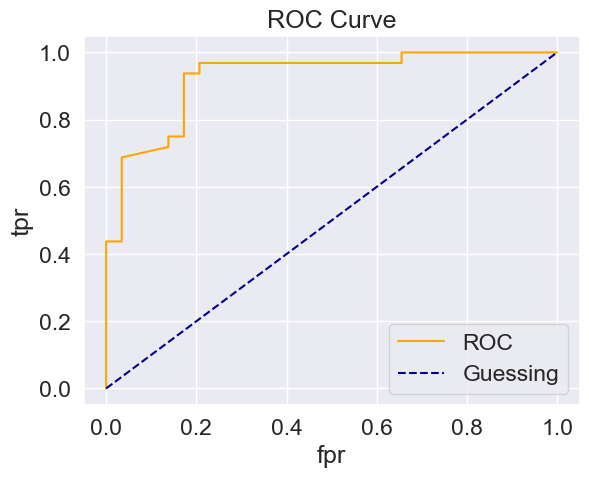

In [203]:
import matplotlib.pyplot as plt
def plot_roc_curve(fpr,tpr):
    """
    Plots a ROC given(fpr)
    & (tpr) of a model
    """
##Plot ROC curve
plt.plot(fpr,tpr,color="orange",label="ROC")
plt.plot([0,1],[0,1],color="darkblue",linestyle="--",label="Guessing")
plt.xlabel("fpr")
plt.ylabel("tpr")
plt.title("ROC Curve")
plt.legend()
plt.show()
plot_roc_curve(fpr,tpr)

In [204]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,y_probs_positive)

0.9251077586206896

In [205]:
fpr,tpr,thresholds=roc_curve(y_test,y_test)
plot_roc_curve(fpr,tpr)
roc_auc_score(y_test,y_test)

1.0

In [206]:
## Confusion matrix
from sklearn.metrics import confusion_matrix
y_preds=model.predict(x_test)
confusion_matrix(y_test,y_preds)

array([[24,  5],
       [ 4, 28]])

In [207]:
pd.crosstab(y_test,
            y_preds,
            rownames=["Actual"],
            colnames=["Predicted"])

Predicted,0,1
Actual,,
0,24,5
1,4,28


In [208]:
len(x_test)

61

In [209]:
##Make confusion matrix visually good

In [210]:
import sys
!conda install --yes --prefix {sys.prefix} seaborn

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.9.1
    latest version: 26.1.0

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.



<Axes: >

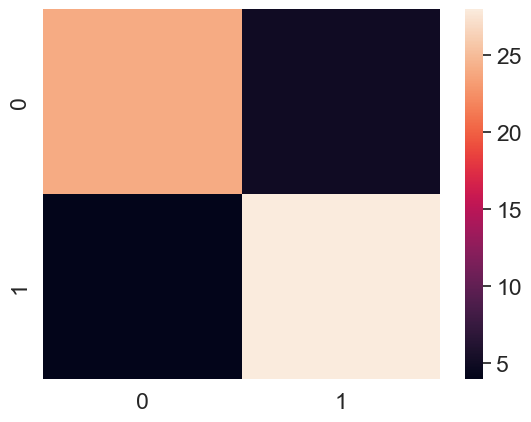

In [211]:
import seaborn as sns
sns.set(font_scale=1.5)
conf_mat=confusion_matrix(y_test,y_preds)
sns.heatmap(conf_mat)

In [212]:
import sklearn
sklearn.__version__

'1.7.2'

In [213]:
## creating a confusion matrix using scikit learn

In [214]:
model

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


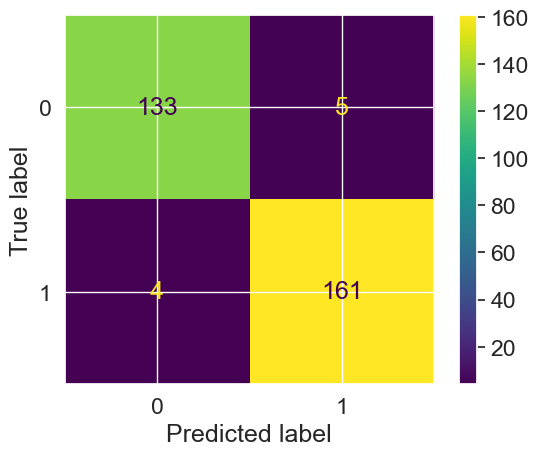

In [215]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(estimator=model,X=x,y=y)

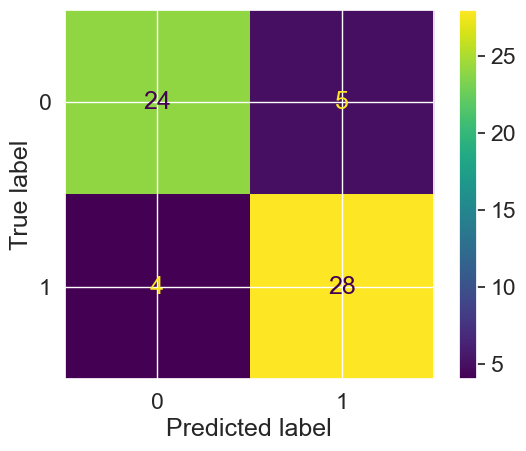

In [216]:
ConfusionMatrixDisplay.from_predictions(y_true=y_test,
                                        y_pred=y_preds)

In [217]:
## 4) Classification report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [218]:
#where precision and recall become valuable
disease_true=np.zeros(10000)
disease_true[0]=1 #only 1 positive case
disease_preds=np.zeros(10000) #model predicts every case as 0
pd.DataFrame(classification_report(disease_true,
                                   disease_preds,
                                   output_dict=True))


/Users/yuvraj/Desktop/Sample1/env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/yuvraj/Desktop/Sample1/env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/yuvraj/Desktop/Sample1/env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

,0.0,1.0,accuracy,macro avg,weighted avg
precision,0.99990,0.0,0.9999,0.499950,0.99980
recall,1.00000,0.0,0.9999,0.500000,0.99990
f1-score,0.99995,0.0,0.9999,0.499975,0.99985
support,9999.00000,1.0,0.9999,10000.000000,10000.00000


## Regression evaluation model1 (r2 score)

In [219]:
from sklearn.ensemble import RandomForestRegressor
np.random.seed(42)
x=housing_df.drop("target",axis=1)
y=housing_df["target"]
x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               test_size=0.2)
model=RandomForestRegressor()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.8059809073051385

In [220]:
from sklearn.metrics import r2_score
#Fill an array with y_test mean
y_test_mean=np.full(len(y_test),y_test.mean())
y_test_mean[:10]
r2_score(y_true=y_test,
         y_pred=y_test_mean)

0.0

In [221]:
r2_score(y_true=y_test,
         y_pred=y_test)

1.0

## Regression evaluation model2 (MAE[mean absolute erro])

In [222]:
from sklearn.metrics import mean_absolute_error
y_preds=model.predict(x_test)
mae=mean_absolute_error(y_test,y_preds)
mae
df=pd.DataFrame(data={"actual":y_test,
                      "predicted":y_preds})
df["difference"]=df["actual"]-df["predicted"]
df.head()

,actual,predicted,difference
20046,0.47700,0.490580,-0.013580
3024,0.45800,0.759890,-0.301890
15663,5.00001,4.935016,0.064994
20484,2.18600,2.558640,-0.372640
9814,2.78000,2.334610,0.445390


In [223]:
np.abs(df["difference"]).mean()

np.float64(0.3270458119670544)

## Regression evaulation model3 Mean Squared Error(MSE)

In [224]:
from sklearn.metrics import mean_squared_error
y_preds=model.predict(x_test)
mse=mean_squared_error(y_test,y_preds)
mse

0.2542443610174998

## Finally using the scoring parameter

In [225]:
## Use page 71 and 72 for this!

## Model evaluation through scikit learn

In [226]:
## Use page 72 for this

## 5) Improving a model

In [227]:
from sklearn.ensemble import RandomForestClassifier
clf=RandomForestClassifier()
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

## 5.1 By hand

In [228]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.ensemble import RandomForestClassifier
def evaluate_preds(y_true,y_preds):
    accuracy=accuracy_score(y_true,y_preds)
    precision=precision_score(y_true,y_preds)
    recall=recall_score(y_true,y_preds)
    f1=f1_score(y_true,y_preds)
    metric_dict={"accuracy":round(accuracy,2),
                 "%precision":round(precision,2),
                 "recall":round(recall,2),
                 "f1":round(f1,2)}
    return metric_dict
np.random.seed(42)
# shuffle the data
heart_disease_shuffled=heart_disease.sample(frac=1)
x=heart_disease_shuffled.drop("target",axis=1)
y=heart_disease_shuffled["target"]
train_split=round(0.7*len(heart_disease_shuffled))
valid_split=round(train_split+0.15*len(heart_disease_shuffled))
x_train,y_train=x[:train_split],y[:train_split]
x_valid,y_valid=x[train_split:valid_split],y[train_split:valid_split]
x_test,y_test=x[valid_split:],y[:valid_split]
len(x_train), len(x_valid), len(x_test)
clf=RandomForestClassifier()
clf.fit(x_train,y_train)
y_preds=clf.predict(x_valid)
baseline_metrics=evaluate_preds(y_valid,y_preds)
baseline_metrics

{'accuracy': 0.82, '%precision': 0.81, 'recall': 0.88, 'f1': 0.85}

In [229]:
## second classifier with different parameter
np.random.seed(42)
clf_2=RandomForestClassifier(n_estimators=100,max_depth=10)
clf_2.fit(x_train,y_train)
y_preds_2=clf_2.predict(x_valid)
clf_2_metrics=evaluate_preds(y_valid,y_preds_2)
clf_2_metrics

{'accuracy': 0.82, '%precision': 0.84, 'recall': 0.84, 'f1': 0.84}

## 5.2 Hyperparameter with RandomizedSearchCV

In [230]:
from sklearn.model_selection import RandomizedSearchCV
grid={"n_estimators":[10,100,200,500,1000,1200],
      "max_depth":[None,5,10,20,30],
      "max_features":["sqrt", "log2", None],
      "min_samples_split":[2,4,6],
      "min_samples_leaf":[1,2,4]}
np.random.seed(42)
x=heart_disease_shuffled.drop("target",axis=1)
y=heart_disease_shuffled["target"]
x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               test_size=0.2)
clf=RandomForestClassifier(n_jobs=1)
#setup RandomizedSearchCV
rs_clf=RandomizedSearchCV(estimator=clf,
                          param_distributions=grid,
                          n_iter=10,
                          cv=5,
                          verbose=2)
#Fit the RandomizedSearchCV version of clf
rs_clf.fit(x_train,y_train)
rs_clf.best_params_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=30, max_features=None, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   0.6s
[CV] END max_depth=30, max_features=None, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   0.6s
[CV] END max_depth=30, max_features=None, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   0.7s
[CV] END max_depth=30, max_features=None, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   0.6s
[CV] END max_depth=30, max_features=None, min_samples_leaf=2, min_samples_split=6, n_estimators=1200; total time=   0.6s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=6, n_estimators=500; total time=   0.3s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=6, n_estimators=500; total time=   0.3s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=6, n_est

{'n_estimators': 1200,
 'min_samples_split': 6,
 'min_samples_leaf': 4,
 'max_features': 'log2',
 'max_depth': 30}

In [231]:
#Make prediction with the best hyperparameter
rs_y_preds=rs_clf.predict(x_test)
rs_metrics=evaluate_preds(y_test,rs_y_preds)
rs_metrics

{'accuracy': 0.84, '%precision': 0.78, 'recall': 0.89, 'f1': 0.83}

## 5.3 Hyperparameter tuning with the Grid Search CV

In [235]:
from sklearn.model_selection import GridSearchCV
grid_2={'n_estimators': [100, 200, 1200],
 'max_depth': [30],
 'max_features': ['log2'],
 'min_samples_split': [6],
 'min_samples_leaf': [2,4]}
np.random.seed(42)
x=heart_disease_shuffled.drop("target",axis=1)
y=heart_disease_shuffled["target"]
x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               test_size=0.2)
clf_2=RandomForestClassifier(n_jobs=1)
#setup RandomizedSearchCV
gs_clf=RandomizedSearchCV(estimator=clf_2,
                          param_distributions=grid_2,
                          cv=5,
                          verbose=2)
#Fit the RandomizedSearchCV version of clf
gs_clf.fit(x_train,y_train)
gs_clf.best_params_

/Users/yuvraj/Desktop/Sample1/env/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=6, n_estimators=100; total time=   0.1s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=6, n_estimators=100; total time=   0.0s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=6, n_estimators=200; total time=   0.1s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=6, n_estimators=200; total time=   0.1s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=2, min_samples_split=6, n_estimators=200;

{'n_estimators': 100,
 'min_samples_split': 6,
 'min_samples_leaf': 4,
 'max_features': 'log2',
 'max_depth': 30}

In [236]:
gs_y_preds=gs_clf.predict(x_test)
gs_metrics=evaluate_preds(y_test,gs_y_preds)
gs_metrics

{'accuracy': 0.84, '%precision': 0.78, 'recall': 0.89, 'f1': 0.83}

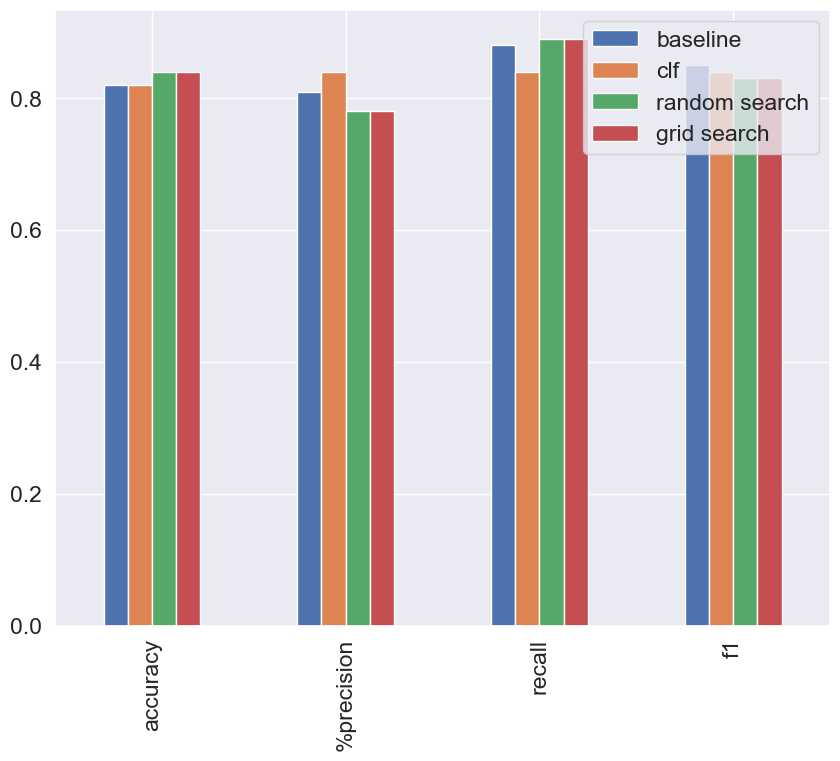

In [237]:
#Lets compare our different model metrics
compare_metrics=pd.DataFrame({"baseline":baseline_metrics,
                              "clf":clf_2_metrics,
                              "random search":rs_metrics,
                              "grid search":gs_metrics})
compare_metrics.plot.bar(figsize=(10,8));